In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('aps.mplstyle')
import set_size_helper as ssh
# importlib.reload(ssh)
from scipy.fftpack import fft
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter as sgf
from matplotlib.ticker import MultipleLocator


In [2]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)
df_i = pd.DataFrame()

idmrg_file_list_dict = {100 : '../../data/iDMRG/rev/scanChi100/corrs/results.h5',
                        200 : '../../data/iDMRG/rev/scanChi200/corrs/results.h5', 
                        600 : '../../data/iDMRG/scanChi600/corrs/results.h5',
                        800 : '../../data/iDMRG/scanChi800/corrs/results.h5',
                        1000: '../../data/iDMRG/scanChi1000/corrs/results.h5',
}
for chi, idmrg_file in idmrg_file_list_dict.items():
    df_i_chi = read_corrs(idmrg_file)
    df_i_chi['chi'] = chi
    df_i = pd.concat([df_i, df_i_chi])
df.keys(), df_i.keys()

(Index(['szmat', 'chargemat', 'spmmat', 'elecupmat', 'elecdnmat', 'sz_expect',
        'ntot_expect', 'xspin2', 'spin2vec', 'params', 'N', 'dV', 'Vpm',
        'szconn', 'chargeconn', 'spmconn', 'electron_conn', 'filename'],
       dtype='str'),
 Index(['basename', 'src_file', 'dV', 'mean_Sz', 'mean_fill', 'xi',
        'model_params', 'diagnostics', 'charge_corr', 'spinz_corr', 'spsm_corr',
        'electron_corr', 'spin2_corr', 'chi'],
       dtype='str'))

0.7071289916568609


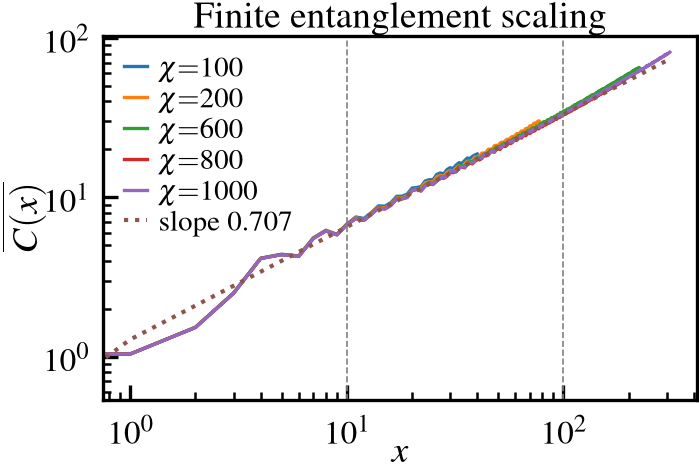

In [3]:
fig, ax = plt.subplots(1)
fig_dims = ssh.set_size(subplots=(1,1), fraction=0.75)
fig.set_size_inches(fig_dims)
chilist = (100, 200, 600, 800, 1000)
for chi in chilist : 
    seldf_i = df_i[df_i['chi']==chi]
    try : 
        # elec_corr = obs.denoise_rolling(np.abs(select_dV(seldf_i, 3.55)['electron_corr']), window=4)
        elec_corr = sgf(np.abs(select_dV(seldf_i, 3.55)['electron_corr']), window_length=5, polyorder=2)
    except :
        print(f"Eror for chi = {chi}")
    rvals = np.arange(len(elec_corr))
    logy = -np.log(elec_corr)
    ax.loglog(rvals, logy, lw=0.8, label=rf'$\chi\!\!= \!\!{{{chi}}}$')

limits = [10, 100]
fs = slice(*limits)
m, c = np.polyfit(np.log(rvals[fs]), np.log(logy[fs]), 1)
[ax.axvline(win, ls='--', lw=0.4, c='gray') for win in limits]
print(m)
ax.loglog(rvals, (np.exp(c) * rvals**m), ls=':', label=f'slope {m:.3f}')
ax.legend(labelspacing=0.12, columnspacing=0.2, fontsize=7, handlelength=0.8)
ax.set_title(r"Finite entanglement scaling", pad=-1)
ax.set_ylabel(r'$\overline{C(x)}$', labelpad=-0.8)
ax.set_xlabel(r'$x$')  
ax.xaxis.set_label_coords(0.5, -0.1)
# fig.savefig('figures/FES_Cx.pdf', bbox_inches='tight')

In [4]:
def fit_succ(x, y, start=0, end=-1, minwin=10):
    if end < 0 : 
        end = len(x) + end
    minm, maxm = 1000., 0.
    minidx = (0,0)
    maxidx = (end, end)
    for ts in range(start, end-minwin):
        for wsize in range(minwin, end-ts):
            fs = slice(ts, ts + wsize)
            m, logc = np.polyfit(x[fs], y[fs], 1)
            if m > maxm: 
                maxm = m
                maxidx = (ts, ts+wsize)
            if m < minm:
                minm = m 
                minidx = (ts, ts+wsize)
    results = (minm, maxm, minidx, maxidx)
    return results

def fit_accum(x, y, start=0, end=-1, winlen=10, covtol=1.):
    if end < 0 : 
        end = len(x) + end
    mlist = []
    startlist = []
    for ts in range(start, end-winlen-1):
            fs = slice(ts, ts + winlen)
            fit, cov = np.polyfit(x[fs], y[fs], 1, cov=True)
            if cov[0,0]*cov[1,1] - cov[1,0]*cov[0,1] < covtol:
                mlist.append(fit[0])
                startlist.append(ts)
    return mlist, startlist




In [5]:
df = read_corrs('../../data/iDMRG/Vpm4.350cc/corrs/results.h5')
df['chi'] = df['src_file'].apply(lambda row : int(row.split('chi')[1].split('.')[0]))
df = df.sort_values('chi')

Error for chi = 200: expected non-empty vector for x
Error for chi = 240: expected non-empty vector for x
Error for chi = 300: expected non-empty vector for x
[0.72720134 0.7318607  0.74878883 0.72969829]


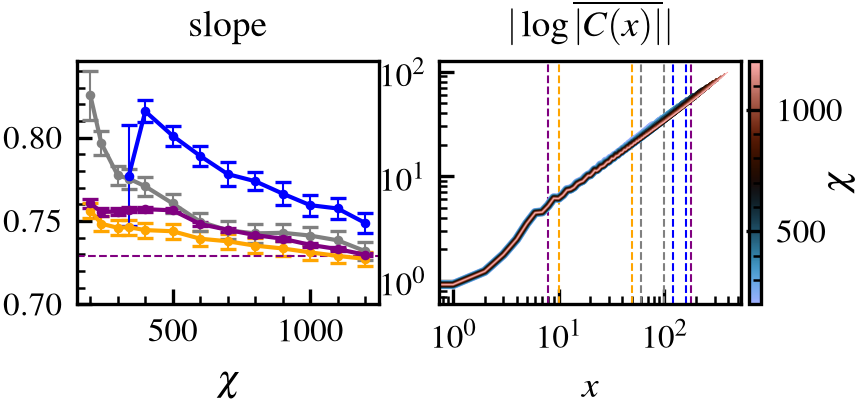

In [29]:
fig, ax = plt.subplots(1, 2)
fig_dims = ssh.set_size(subplots=(1,2), fraction=1.0)
fig.set_size_inches(fig_dims)
chilist = np.array([200, 240, 300, 340, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200])
norm = mpl.colors.Normalize(vmin=min(chilist), vmax=max(chilist))
# cmap = plt.cm.viridis_r
cmap = plt.cm.berlin

fitwinlist = [(10, 50), (60, 100), (120, 160), (8, 180)]
fitcols = ['orange', 'gray', 'blue', 'purple']
for fitwin in fitwinlist:
    [ax[1].axvline(fitb, c=fitcols[fitwinlist.index(fitwin)], ls='--', lw=0.5) for fitb in fitwin]


mlist = []
clist = []
varlist = []
for idx in range(len(fitwinlist)):
    mlist.append([]), clist.append([]), varlist.append([])
for chi in chilist:
    seldf = df[df['chi'] == chi]
    yvals = np.abs(obs.denoise_rolling(np.abs(seldf['electron_corr'].values[0]), 4))
    # yvals = sgf(np.abs(seldf['electron_corr'].values[0]), window_length=4, polyorder=1)
    xvals = np.arange(len(yvals))
    yvals = np.abs(yvals)
    logyvals = np.abs(np.log(yvals))
    ax[1].loglog(xvals, logyvals, ls='-', c=cmap(norm(chi)), lw=2*np.abs(1-norm(chi) + 1e-1))
    # ax[1].loglog(xvals, logyvals, ls='-', c=cmap(norm(chi)), lw=0.4, alpha=0.8)
    for idx, fitwin in enumerate(fitwinlist):
        fs = slice(*fitwin)
        try :
            p, cov = np.polyfit(np.log(xvals[fs]), np.log(logyvals[fs]), 1, cov=True)
            m, c = p
            mlist[idx].append(m)
            clist[idx].append(c)
            varlist[idx].append(cov[0,0])
        except Exception as e:
            print(f"Error for chi = {chi}: {e}")
            mlist[idx].append(np.nan)
            clist[idx].append(np.nan)
            varlist[idx].append(np.nan)


sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r"$\chi$", labelpad=-5)

# m, c = np.polyfit(np.log(xvals[fs]), np.log(logyvals[fs]), 1)
# m, c = mlist[-1], clist[-1]
# ax[1].loglog(xvals, np.exp(c) * xvals**m, ls=':')
# print(m)
for idx, m in enumerate(mlist):
    ax[0].errorbar(chilist, m, yerr=np.sqrt(varlist[idx]), fmt='.-', capsize=2, elinewidth=0.5, markersize=3, c=fitcols[idx])
ax[0].set_xlabel(r'$\chi$')
ax[0].set_title('slope')
# ax[0].plot(chilist, np.sqrt(varlist), '.-') #stddev is ~0.01 for all
# ax[0].set_xscale('log') 
ax[1].set_xlabel(r'$x$')
ax[1].set_title(r'$|\log\overline{|C(x)|}|$')
ax[0].set_ylim([0.70, None])
ax[0].yaxis.set_major_locator(MultipleLocator(0.05))
ax[0].yaxis.minorticks_on()
ax[0].yaxis.set_minor_locator(MultipleLocator(0.01))

ax[0].axhline(0.729, ls='--', lw=0.5, c='purple')
print(np.array(mlist).T[-1])
fig.savefig('figures/finite_ent_scalingv3.pdf')